In [1]:
#pip install numpy pandas matplotlib seaborn scikit-learn keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Obtención de datos
# Leer el archivo
houseprices=pd.read_csv("houseprices.csv")
houseprices.head(20)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [3]:
houseprices.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
## Separar variables objetivo
X=houseprices.drop(columns=["SalePrice"])
y=houseprices["SalePrice"]


# Elimino el Id en realidad no aporta informacion importante
X=X.drop(columns=["Id"])

In [5]:
# Identificar variables numéricas y categóricas
numeric_features=X.select_dtypes(include=["int64","float64"]).columns
categorical_features=X.select_dtypes(include=["object"]).columns

#Imprimir las variables numéricas y categóricas
print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)

Variables numéricas: Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='str')
Variables categóricas: Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20144\2574283277.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features=X.select_dtypes(include=["object"]).columns


In [7]:
# librerías para preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [8]:
# Inicialmente vamos a ensayar rellenando los valores faltantes
#Simpleimputer permite rellenar valores faltantes
#standardscaler escalar las variables numericas media=0 y desviacion estandar=1
# one hot encoder convierte las variables categoricas a variables dummy (0 y 1)



#numericas
# - Escalar variables
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categóricas:
# - Rellenar NaN con la moda
# - Convertir categorías a variables dummy
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


In [9]:
# Combinar preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=101)

In [11]:
# 6. Aplicar transformación
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Tamaño X_train procesado:", X_train_processed.shape)
print("Tamaño X_test procesado:", X_test_processed.shape)

Tamaño X_train procesado: (1168, 284)
Tamaño X_test procesado: (292, 284)


### Regresión Lineal

In [12]:
#Importar función
from sklearn.linear_model import LinearRegression

In [13]:
# Crear instancia del modelo
model = LinearRegression()

# Entrenar el modelo
model.fit(X_train_processed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
# Mostrar coeficientes
print("Coeficientes del modelo:", model.coef_)
print("Intercepto del modelo:", model.intercept_)

Coeficientes del modelo: [-1.03587040e+03  1.54468539e+03  6.76816756e+03  9.36064463e+03
  6.68747623e+03  8.07492632e+03  1.42733676e+03  4.14697945e+03
  7.27989806e+03  1.90761660e+03 -1.81185616e+03  6.49218155e+03
  7.68869266e+03  1.30823334e+04 -2.08963810e+03  1.63824932e+04
 -6.80890252e+02 -8.98526483e+02  1.13032368e+03 -1.32293068e+01
 -3.70137680e+03 -3.03223323e+03  2.65459233e+03  1.27577733e+03
  9.83929592e+02  2.84352954e+03  2.45817444e+03  1.93803246e+03
  7.81960317e+02 -4.68394640e+02  7.63930044e+02  1.81460871e+03
  1.01504179e+04  2.99751776e+03 -1.20849968e+03 -5.23099428e+02
 -1.24739140e+04  6.00080085e+03  1.20308819e+04 -3.26276044e+02
 -5.23149272e+03 -1.82888906e+04  1.82888906e+04 -2.71943153e+02
  2.71943153e+02 -3.03509799e+03  1.58105067e+03  4.41492814e+03
 -2.96088082e+03 -9.20470403e+02  5.53151981e+03 -1.01670422e+04
  5.55599284e+03  2.23024798e+04 -2.23024798e+04  4.95230530e+03
  1.27548549e+04 -4.62535315e+03 -1.55873881e+04  2.50558108e+03


In [15]:
# prediccion
y_pred = model.predict(X_test_processed)


Text(0.5, 1.0, 'Valores Reales vs Predichos')

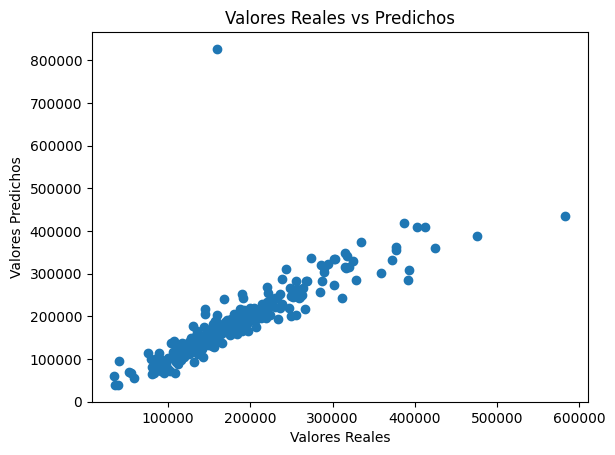

In [16]:
# Grafico de prueba frente a valores previstos
plt.scatter(y_test, y_pred)
plt.xlabel("Valores Reales")    
plt.ylabel("Valores Predichos")
plt.title("Valores Reales vs Predichos")


In [17]:
# Evaluación del modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 18986.318388899002
RMSE: 46214.38177459405
R2: 0.6412328373831278


CONCLUSIONES
* El modelo presenta un R2 de 0.64, es moderado la capacidad que tiene el modelo para interpretar el nivel del precio de la vivienda.
*  Al tener una gran diferencia entre el RMSE y MAE, existe errores grandes en ciertar observaciones pueden darse por algunos outliers.
